In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

# Load model
model = load_model('./gru/Quickdraw5Class1.h5')
model_8020 = load_model('./gru/Quickdraw5Class1_20.h5')

# Load test data
X_test = np.load('X_test.npy', allow_pickle=True)
y_test = np.load('y_test.npy', allow_pickle=True)

In [3]:
X_testzero = np.zeros((len(X_test), 100, 3))

for x in range(len(X_test)):
    for y in range(100):
        for z in range(3):
            if y >= len(X_test[x]):
                break
            X_testzero[x][y][z] = X_test[x][y][z]

In [4]:
# encode labels for 5 classes
num_classes = 5
y_labhot = np.zeros((len(y_test),5))

y_labhot.shape

num = 0
for x in y_test:
  if x == 0:
    y_labhot[num][0] = 1
  elif x == 1: 
    y_labhot[num][1] = 1
  elif x == 2: 
    y_labhot[num][2] = 1
  elif x == 3: 
    y_labhot[num][3] = 1
  elif x == 4: 
    y_labhot[num][4] = 1
  num = num + 1

In [5]:
loss, acc = model.evaluate(X_testzero, y_labhot, batch_size=512, verbose=1)
print(f"GRU Test Loss: {loss:.4f}")
print(f"GRU Test Accuracy: {acc:.4f}")

25/25 [==============================] - 1s 23ms/step - loss: 0.3057 - accuracy: 0.8957
GRU Test Loss: 0.3057
GRU Test Accuracy: 0.8957


In [6]:
y_pred_probs = model.predict(X_testzero, batch_size=512)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_labhot, axis=1)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred, target_names=['ant', 'bee', 'butterfly', 'mosquito', 'snail']))

25/25 [==============================] - 1s 22ms/step
              precision    recall  f1-score   support

         ant       0.96      0.80      0.87      2500
         bee       0.94      0.84      0.89      2500
   butterfly       0.97      0.96      0.96      2500
    mosquito       0.70      0.93      0.80      2500
       snail       0.99      0.95      0.97      2500

    accuracy                           0.90     12500
   macro avg       0.91      0.90      0.90     12500
weighted avg       0.91      0.90      0.90     12500



In [7]:
loss, acc = model_8020.evaluate(X_testzero, y_labhot, batch_size=512, verbose=1)
print(f"GRU Test Loss: {loss:.4f}")
print(f"GRU Test Accuracy: {acc:.4f}")

25/25 [==============================] - 1s 22ms/step - loss: 0.2525 - accuracy: 0.9230
GRU Test Loss: 0.2525
GRU Test Accuracy: 0.9230


In [8]:
y_pred_probs = model_8020.predict(X_testzero, batch_size=512)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_labhot, axis=1)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred, target_names=['ant', 'bee', 'butterfly', 'mosquito', 'snail']))

25/25 [==============================] - 1s 21ms/step
              precision    recall  f1-score   support

         ant       0.90      0.95      0.92      2500
         bee       0.95      0.87      0.91      2500
   butterfly       0.97      0.96      0.96      2500
    mosquito       0.83      0.87      0.85      2500
       snail       0.98      0.97      0.98      2500

    accuracy                           0.92     12500
   macro avg       0.93      0.92      0.92     12500
weighted avg       0.93      0.92      0.92     12500



Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 100, 3)]          0         
                                                                 
 gru (GRU)                   (None, 100, 32)           3552      
                                                                 
 flatten (Flatten)           (None, 3200)              0         
                                                                 
 dense (Dense)               (None, 32)                102432    
                                                                 
 relu_0 (Activation)         (None, 32)                0         
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528   

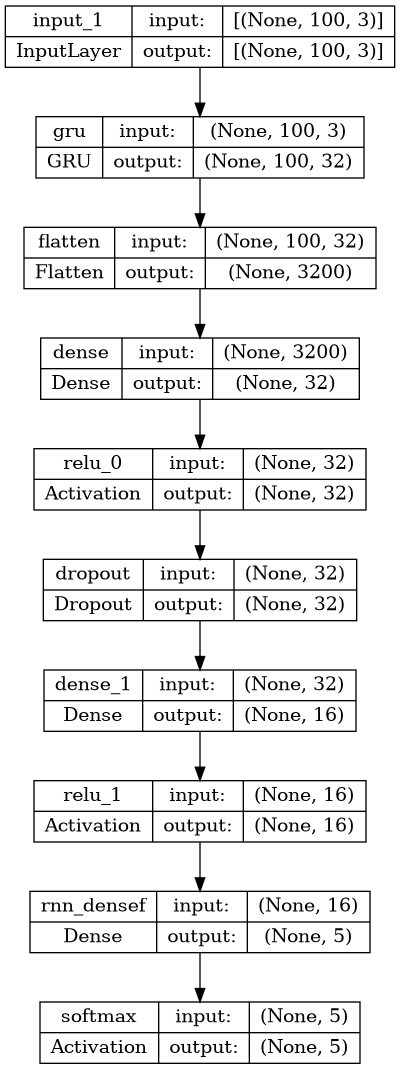

In [9]:
from tensorflow.keras.utils import plot_model

model.summary()
plot_model(model, show_shapes=True, show_layer_names=True)